# 08 — Held-out Perplexity

Quantitative complement to the classifier attribution in `06_evaluation.ipynb`.
For each adapter we measure perplexity on every artist's **held-out** lyrics
(`data/eval.csv`), conditioned on the fixed training prompt (which is masked, so
only the lyric continuation is scored).

The result is a cross-artist matrix. If an adapter genuinely specialized, its
column-minimum lands on the diagonal — i.e. each artist's lyrics are best
predicted (lowest perplexity) by that artist's own adapter, and every adapter
beats the base model on its target artist.

Core logic lives in `perplexity.py` (CPU-tested); this notebook just runs the
forward passes, which need the GPU.

In [1]:
import pandas as pd

from generation.model import load_base_model
from evaluation.perplexity import perplexity_matrix, plot_perplexity_matrix

base_model, tokenizer = load_base_model()

eval_df = pd.read_csv("./data/eval.csv")
eval_df["artist"].value_counts()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

/home/aliozkaya/uni/467/term_project/src/.venv/lib/python3.14/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


artist
Meshuggah    12
Opeth        12
Death        12
Gojira        8
Tool          7
Name: count, dtype: int64

In [2]:
from config import main_adapters, Adapter

# Rows: base + one headline adapter (LoRA r8) per artist, plus the SW variant.
# Only adapters that exist on disk are included (skip not-yet-trained ones).
specs = main_adapters() + [Adapter("Gojira", "lora", 8, sw=True)]
adapter_map = {"base": None}
for a in specs:
    if a.path.exists():
        key = a.artist.lower() + ("_sw" if a.sw else "")
        adapter_map[key] = str(a.path)

ppl = perplexity_matrix(base_model, tokenizer, adapter_map, eval_df)
ppl.round(1)

base: Death=30.2  Gojira=50.0  Meshuggah=149.1  Opeth=115.6  Tool=25.1
gojira: Death=15.2  Gojira=22.5  Meshuggah=74.8  Opeth=59.4  Tool=12.9
tool: Death=16.0  Gojira=30.9  Meshuggah=84.2  Opeth=66.9  Tool=10.2
death: Death=5.2  Gojira=68.5  Meshuggah=209.7  Opeth=180.1  Tool=33.2
meshuggah: Death=17.2  Gojira=34.3  Meshuggah=51.8  Opeth=72.4  Tool=15.9
opeth: Death=16.8  Gojira=32.3  Meshuggah=85.9  Opeth=36.1  Tool=14.4
gojira_sw: Death=17.2  Gojira=26.7  Meshuggah=88.4  Opeth=70.1  Tool=14.4


,Death,Gojira,Meshuggah,Opeth,Tool
base,30.2,50.0,149.1,115.6,25.1
gojira,15.2,22.5,74.8,59.4,12.9
tool,16.0,30.9,84.2,66.9,10.2
death,5.2,68.5,209.7,180.1,33.2
meshuggah,17.2,34.3,51.8,72.4,15.9
opeth,16.8,32.3,85.9,36.1,14.4
gojira_sw,17.2,26.7,88.4,70.1,14.4


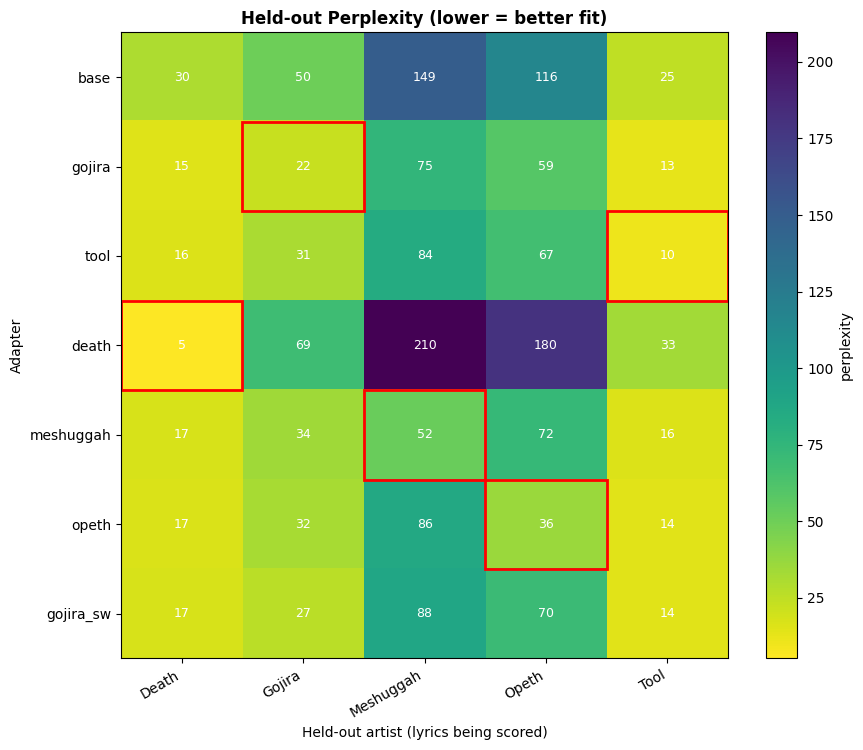

In [3]:
plot_perplexity_matrix(ppl)

## Reading the matrix

- **Lower = better fit.** Red boxes mark the per-column minimum.
- **Specialization:** each adapter's perplexity on its own artist should be the
  lowest in that column, and below the `base` row.
- **Cross-talk:** Gojira and Tool sit close in style, so off-diagonal cells will
  not be huge — the relevant signal is the *ordering* (own-artist lowest), not
  the absolute gap.
- Pairs with the attribution numbers in `06_evaluation.ipynb`: attribution says
  "the output reads like artist X"; perplexity says "the adapter assigns higher
  likelihood to artist X's real lyrics". Two independent angles on the same claim.